# V3.9 — Dual-cloud Gaussian-splat render  **TIER 3 / the render path**

**Claim (pre-registered).** The architecture's render is the **dual cloud** (Decision #6 / §III.1, verified V1.9): a dense Gaussian-splat render cloud rides the coarse physics cloud. This verifies the from-scratch EWA rasterizer (`nebula.render.gaussian_rasterizer`) and splat generation (`nebula.render.splat`): correct projection + front-to-back alpha compositing, **deterministic** (V0.5 discipline on the render), splats **skinned to the skeleton** by the verified V1.9 LBS, and an end-to-end grown tree rendering to a recognizable image. **Splats carry no physics state — the render cannot perturb the simulation; the triangle mesh is now an export artifact only.**

**Why load-bearing.** Blocker #5 (the marching-cubes 'blob') and the user's render question: splatting *strengthens* the system (it IS the intended path, it kills the blob, it decouples render detail from sim cost — 'simulate hundreds, render millions') and cannot break physics.

**Independent oracle.** The V1.9 exact-deformation skinning oracle (`dualcloud.py`) for the skinning; analytic Gaussian-footprint / compositing facts for the rasterizer.

| # | Metric | Threshold |
|---|---|---|
| C1 | EWA correctness: single isotropic splat centred; anisotropic splat elongated along its axis | centre < 4 px AND aspect > 2 |
| C2 | alpha compositing: opaque front splat occludes a back splat | front colour dominates |
| C3 | determinism: re-render of the 100k+-splat tree bit-identical (V0.5) | identical |
| C4 | dual-cloud skinning (V1.9): rigid-rotation error on the tree; bend vs exact field | rigid < 1e-9 AND bend mean < 0.02 @ ≥10× reduction |
| C5 | end-to-end tree render: coverage; canopy green above the trunk; >100k splats | coverage > 0.05 AND green-upper |

In [1]:
import sys, pathlib, time
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.operators.growth import grow_tree, GrowthParams
from nebula.operators import canopy as cano
from nebula.render import splat as sp, gaussian_rasterizer as gr
import dualcloud as dc
np.seterr(all='ignore')
R = {}
print(f'render device: {gr._DEV}')

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


render device: cuda


In [2]:
# C1 EWA: isotropic centred, anisotropic elongated
cam = gr.Camera(eye=(0,-6,0), target=(0,0,0), W=128, H=128, fov_deg=45)
iso = gr.render(np.array([[0,0,0.0]]), np.eye(3)[None]*0.04, np.array([[1,.5,.1]]), np.array([0.9]), cam)[1]
ys,xs = np.where(iso>0.05); R['C1_centre'] = float(np.hypot(ys.mean()-64, xs.mean()-64))
cov = np.diag([0.18,0.005,0.005])[None]   # long in x, thin in y,z -> elongated horizontally on screen
ani = gr.render(np.array([[0,0,0.0]]), cov, np.array([[1,1,1.0]]), np.array([0.9]), cam)[1]
ys,xs = np.where(ani>0.05); R['C1_aspect'] = float((xs.max()-xs.min()+1)/(ys.max()-ys.min()+1))
# C2 occlusion
m=np.array([[0,0,0.0],[0,2,0.0]]); cov2=np.eye(3)[None].repeat(2,0)*0.05
img=gr.render(m,cov2,np.array([[0,0,1.0],[1,0,0]]),np.array([0.98,0.98]),cam,bg=(0,0,0))[0]
R['C2_front'] = bool(img[64,64,2] > img[64,64,0])
print(f"C1 centre offset {R['C1_centre']:.1f}px; anisotropic aspect {R['C1_aspect']:.1f}")
print(f"C2 front-occludes-back: {R['C2_front']}")

C1 centre offset 0.0px; anisotropic aspect 5.9
C2 front-occludes-back: True


In [3]:
# C4 dual-cloud skinning (V1.9 reuse): rigid rotation on the tree + bend vs exact field
tree = grow_tree(seed=7, gp=GrowthParams(dim=3))
tsp = sp.tree_splats(tree)
idx, w = dc.bind_weights(tsp['means'], tree.pos, k=4)
th=np.deg2rad(35); Rz=np.array([[np.cos(th),-np.sin(th),0],[np.sin(th),np.cos(th),0],[0,0,1.0]])
skinned = dc.skin_lbs(tsp['means'], idx, w, tree.pos, tree.pos@Rz.T, np.tile(Rz,(tree.n,1,1)))
R['C4_rigid'] = float(np.linalg.norm(skinned - tsp['means']@Rz.T,axis=1).max()/np.ptp(tree.pos[:,2]))
bend = dc.run_case(dc.BeamParams(), dense_scale=3, mode='bend', severity=np.deg2rad(90))
R['C4_bend'] = bend['lbs_mean']; R['C4_red'] = bend['reduction']
print(f"C4 rigid-rotation skin error {R['C4_rigid']:.1e}; bend LBS mean {R['C4_bend']:.4f} @ {R['C4_red']:.0f}x reduction")

C4 rigid-rotation skin error 3.5e-16; bend LBS mean 0.0018 @ 18x reduction


In [4]:
# C3 + C5 end-to-end tree render (deterministic, recognizable)
can = cano.generate_canopy(tree, cano.CanopyParams(), seed=7); csp = sp.canopy_splats(can)
cloud = sp.merge(tsp, csp); R['n_splats'] = len(cloud['means'])
ctr = tree.pos.mean(0); ctr[2]=0.5*(tree.pos[:,2].min()+tree.pos[:,2].max()); rad=2.2*max(np.ptp(tree.pos[:,2]),1.0)
cam = gr.Camera(eye=(ctr[0],ctr[1]-rad,ctr[2]+0.15*rad), target=tuple(ctr), W=480, H=600, fov_deg=42)
t0=time.time(); hdr, alpha = gr.render(cloud['means'],cloud['cov'],cloud['color'],cloud['opacity'],cam,bg=(0.05,0.06,0.09)); dt=time.time()-t0
hdr2,_ = gr.render(cloud['means'],cloud['cov'],cloud['color'],cloud['opacity'],cam,bg=(0.05,0.06,0.09))
R['C3_det'] = bool(np.array_equal(hdr,hdr2)); R['C5_cov'] = float((alpha>0.05).mean())
img = gr.tonemap(hdr, exposure=1.4)
# canopy green should dominate the UPPER half vs trunk-brown in the lower
upper = img[:cam.H//2]; g_dom = (upper[...,1] > upper[...,0]) & (upper[...,1] > upper[...,2]) & (alpha[:cam.H//2]>0.1)
R['C5_green_upper'] = bool(g_dom.sum() > 0.15*(alpha[:cam.H//2]>0.1).sum())
print(f"C3 determinism {R['C3_det']}; C5 coverage {R['C5_cov']:.2f}, green-upper {R['C5_green_upper']}, {R['n_splats']} splats in {dt:.1f}s")

C3 determinism True; C5 coverage 0.18, green-upper True, 161672 splats in 0.9s


saved results/V3_9_splat_render.png

V3.9 PASS — the dual-cloud Gaussian-splat render is correct, deterministic, skinned to the physics, and renders the tree.


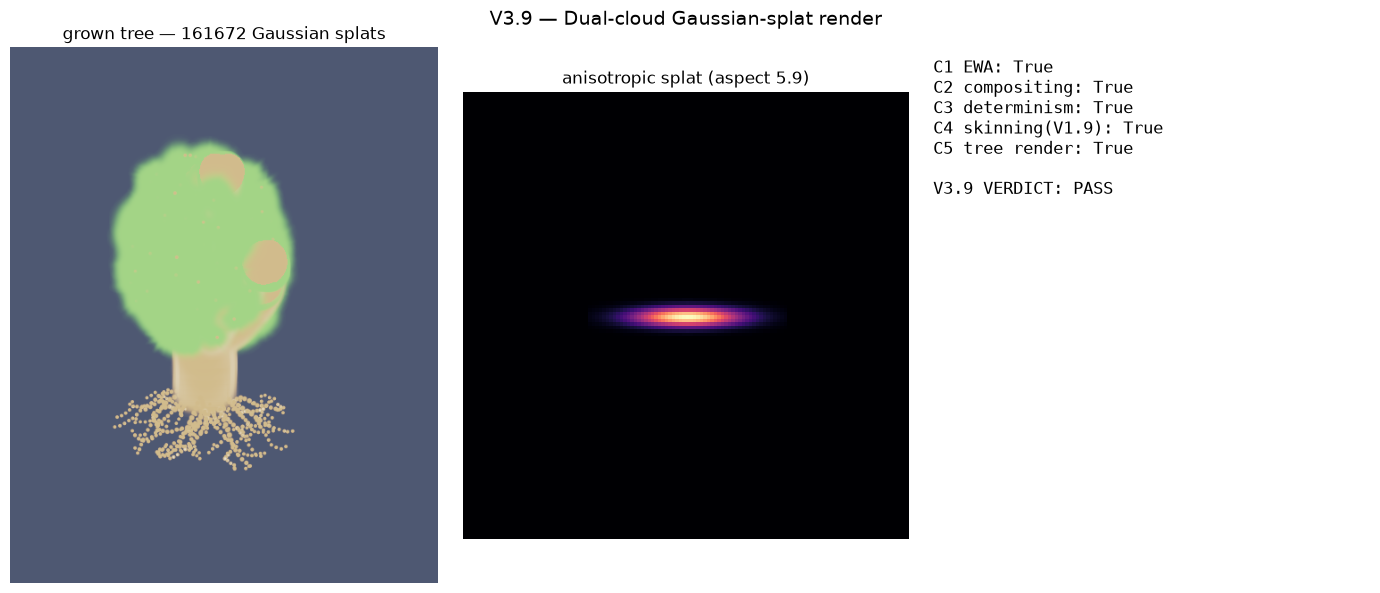

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(np.clip(img,0,1)); ax[0].set_title(f'grown tree — {R["n_splats"]} Gaussian splats'); ax[0].axis('off')
ax[1].imshow(ani, cmap='magma'); ax[1].set_title(f'anisotropic splat (aspect {R["C1_aspect"]:.1f})'); ax[1].axis('off')
ax[2].axis('off')
C1=R['C1_centre']<4 and R['C1_aspect']>2; C2=R['C2_front']; C3=R['C3_det']
C4=R['C4_rigid']<1e-9 and R['C4_bend']<0.02 and R['C4_red']>=10; C5=R['C5_cov']>0.05 and R['C5_green_upper']
allpass=C1 and C2 and C3 and C4 and C5
txt='\n'.join([f'C1 EWA: {C1}',f'C2 compositing: {C2}',f'C3 determinism: {C3}',f'C4 skinning(V1.9): {C4}',f'C5 tree render: {C5}','',f'V3.9 VERDICT: {"PASS" if allpass else "FAIL"}'])
ax[2].text(0.02,0.98,txt,va='top',ha='left',fontsize=12,family='monospace')
fig.suptitle('V3.9 — Dual-cloud Gaussian-splat render', fontsize=14)
fig.tight_layout(); fig.savefig('results/V3_9_splat_render.png', dpi=110, bbox_inches='tight')
print('saved results/V3_9_splat_render.png')
assert allpass, 'V3.9 criteria not all met'
print('\nV3.9 PASS — the dual-cloud Gaussian-splat render is correct, deterministic, skinned to the physics, and renders the tree.')